# <!-- TITLE --> First VAE, using functional API (MNIST dataset)
<!-- DESC --> Construction and training of a VAE, using functional API, with a latent space of small dimension.

## Objectives :
 - Understanding and implementing a **variational autoencoder** neurals network (VAE)
 - Understanding **Keras functional API**, using two custom layers

The calculation needs being important, it is preferable to use a very simple dataset such as MNIST to start with.  
...MNIST with a small scale if you haven't a GPU

## What we're going to do :

 - Defining a VAE model
 - Build the model
 - Train it
 - Have a look on the train process

## Acknowledgements :
Thanks to **François Chollet** who is at the base of this example (and the creator of Keras !!).  
See : https://keras.io/examples/generative/vae


## Step 1 - Init python stuff

In [2]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers

import numpy as np

from modules.layers    import SamplingLayer, VariationalLossLayer
from modules.callbacks import ImagesCallback
from modules.datagen   import MNIST

import sys
import fidle


## Step 2 - Parameters
`scale` : With scale=1, we need 1'30s on a GPU V100 ...and >20' on a CPU !\
`latent_dim` : 2 dimensions is small, but usefull to draw !\
`fit_verbosity`: Verbosity of training progress bar: 0=silent, 1=progress bar, 2=One line  

`loss_weights` : Our **loss function** is the weighted sum of two loss:
 - `r_loss` which measures the loss during reconstruction.  
 - `kl_loss` which measures the dispersion.  

The weights are defined by: `loss_weights=[k1,k2]` where : `total_loss = k1*r_loss + k2*kl_loss`  
In practice, a value of \[1,.06\] gives good results here.  

With scale=0.2, epochs=10 : 3'30 on a laptop


In [ ]:
latent_dim    = 2 #dimension espace latent
loss_weights  = [1,.06] # 1 Reconstruction loss et 0.06 KL loss opti ressemblance loi 
#la tâche de recontsruction est + difficile que la tache de prediction de mean et var
scale         = 0.1 # 10% tot 
seed          = 123

batch_size    = 64
epochs        = 10
fit_verbosity = 1

## Step 3 - Prepare data
`MNIST.get_data()` return : `x_train,y_train, x_test,y_test`,  \
but we only need x_train for our training.

Seeded (123)
Dataset loaded.
Concatenated.
Shuffled.
rescaled (0.1).
Normalized.
Reshaped.
splited (1).
x_train shape is  :  (7000, 28, 28, 1)
x_test  shape is  :  (0, 28, 28, 1)
y_train shape is  :  (7000,)
y_test  shape is  :  (0,)
Blake2b digest is :  b92de405fade06d38f72


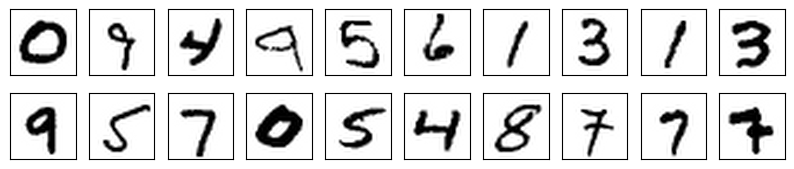

In [ ]:
x_data, y_data, _,_ = MNIST.get_data(seed=seed, scale=scale, train_prop=1 )
#c'est ici qu'on a choisi pas de test en faite
#on a pas de métrique actuellemnt pour juger à quelle point un modèle génératif est performant (à part KL)
#Mais KL n'est performant que pour les lois facile et tranquille
#on va une métrique de control pour les GANs pour voir la distance entre deux distributions
fidle.scrawler.images(x_data[:20], None, indices='all', columns=10, x_size=1,y_size=1,y_padding=0, save_as='01-original')

We only use $y$ for visualization purposes. It is not used by the model since this is an unsupervised learning setting. The labels simply allow us to visually assess how the latent space is structured.

## Step 4 - Build model
In this example, we will use the **functional API** to buikd the following model.

<img width="500px" src="./img/model1.png"></img>

For this, we will use two custom layers :
 - `SamplingLayer`, which generates a vector z from the parameters z_mean and z_log_var - See : [SamplingLayer.py](./modules/layers/SamplingLayer.py)
 - `VariationalLossLayer`, which allows us to calculate the loss function, loss - See : [VariationalLossLayer.py](./modules/layers/VariationalLossLayer.py)

#### Encoder

In [5]:
inputs    = keras.Input(shape=(28, 28, 1)) #taille image en entrée
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(16, activation="relu")(x)
#on récup mean et variance pour caractérisé une normale law 
#pk on fait avec log var ?
z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z         = SamplingLayer()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,932 (558.33 KB)

 Trainable params: 142,932 (558.33 KB)

 Non-trainable params: 0 (0.00 B)

#### Decoder

In [6]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs) #même taille que la dernière couche de l'encoder  
x       = layers.Reshape((7, 7, 64))(x) # reshape ? à quoi ça sert ?
x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(inputs, outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,017 (398.50 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 0 (0.00 B)

#### VAE

We will calculate the loss with a specific layer: `VariationalLossLayer`  
See our : modules.layers.[VariationalLossLayer.py](./modules/layers/VariationalLossLayer.py)

In [7]:
inputs  = keras.Input(shape=(28, 28, 1))
#pk on récupère z_mean et z_log_var ?
z_mean, z_log_var, z = encoder(inputs)
outputs              = decoder(z)

#ok d'avoir le même nom de variable ?

outputs = VariationalLossLayer(loss_weights=loss_weights)([inputs, z_mean, z_log_var, outputs])

vae     = keras.Model(inputs,outputs)

vae.compile(optimizer='adam', loss=None)

## Step 5 - Train
### 5.1 - Using two nice custom callbacks :-)
Two custom callbacks are used:
 - `ImagesCallback` : qui va sauvegarder des images durant l'apprentissage - See [ImagesCallback.py](./modules/callbacks/ImagesCallback.py)
 - `BestModelCallback` : qui sauvegardera le meilleur model - See [BestModelCallback.py](./modules/callbacks/BestModelCallback.py)

In [8]:
run_dir = '.'

callback_images      = ImagesCallback(x=x_data, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]

### 5.2 - Let's train !
With `scale=1`, need 1'15 on a GPU (V100 at IDRIS) ...or 20' on a CPU  

In [9]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(x_data, epochs=epochs, batch_size=batch_size, 
                  callbacks=callbacks_list, verbose=fit_verbosity)

chrono.show()

Epoch 1/10


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step/step - loss: 24001.322
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - loss: 18139.7910
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step/step - loss: 13292.310
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - loss: 13052.0801
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step/step - loss: 12625.656
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - loss: 12492.5625
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step/step - loss: 12231.532
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - loss: 12144.0605
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step/step - loss: 12042.166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
110/110 ━━━━━━━━━━━

## Step 6 - Training review
### 6.1 - History

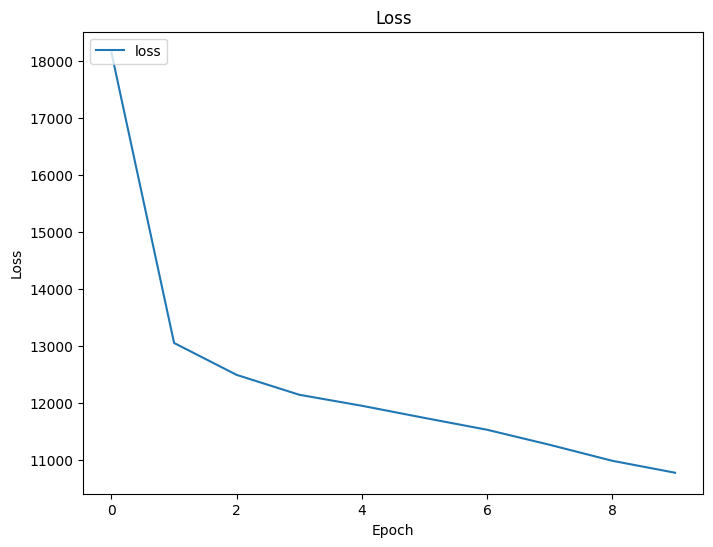

In [10]:
fidle.scrawler.history(history,  plot={"Loss":['loss']})
#pas de val loss, pas utilisé dans l'entrainement ?

### 6.2 - Reconstruction during training
At the end of each epoch, our callback saved some reconstructed images.  
Where :  
Original image -> encoder -> z -> decoder -> Reconstructed image

<br>**Original images :**

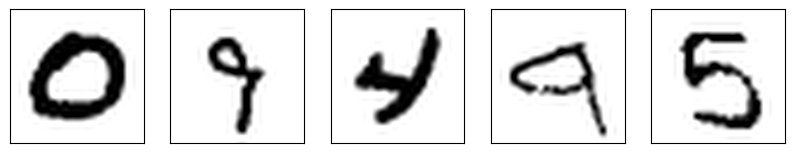

<br>**Encoded/decoded images**

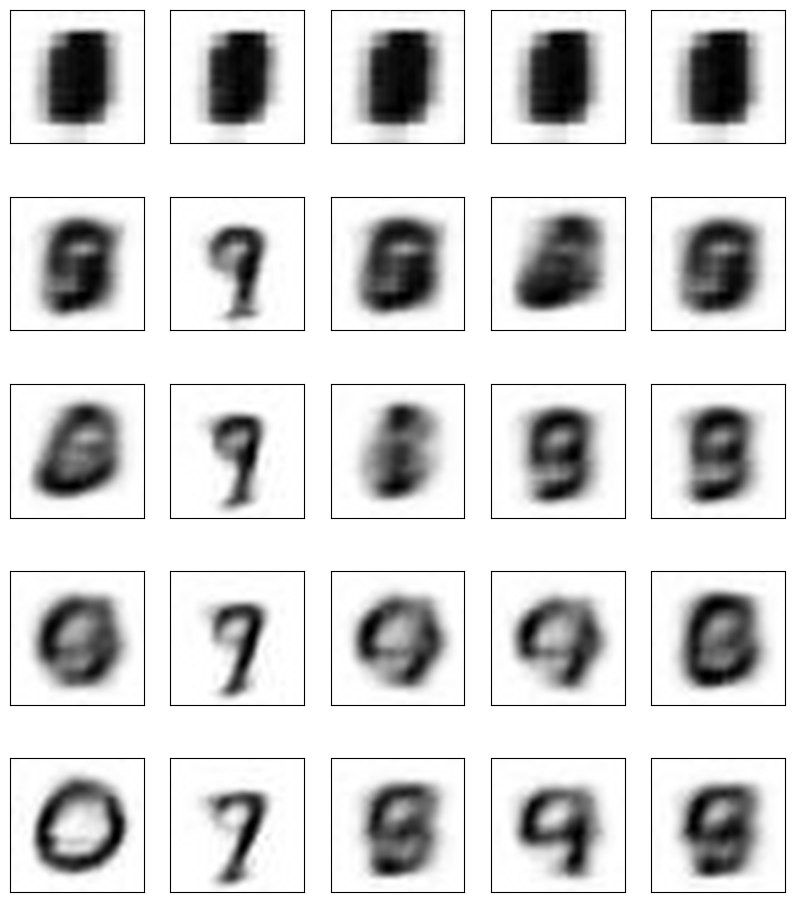

<br>**Original images :**

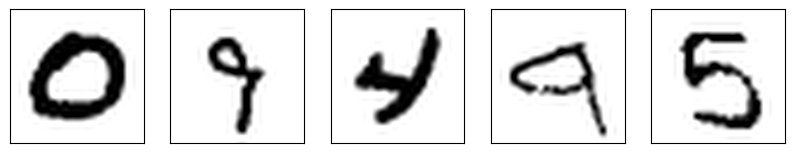

In [11]:
images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-reconstruct')

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)


### 6.3 - Generation (latent -> decoder)

<br>**Generated images from latent space**

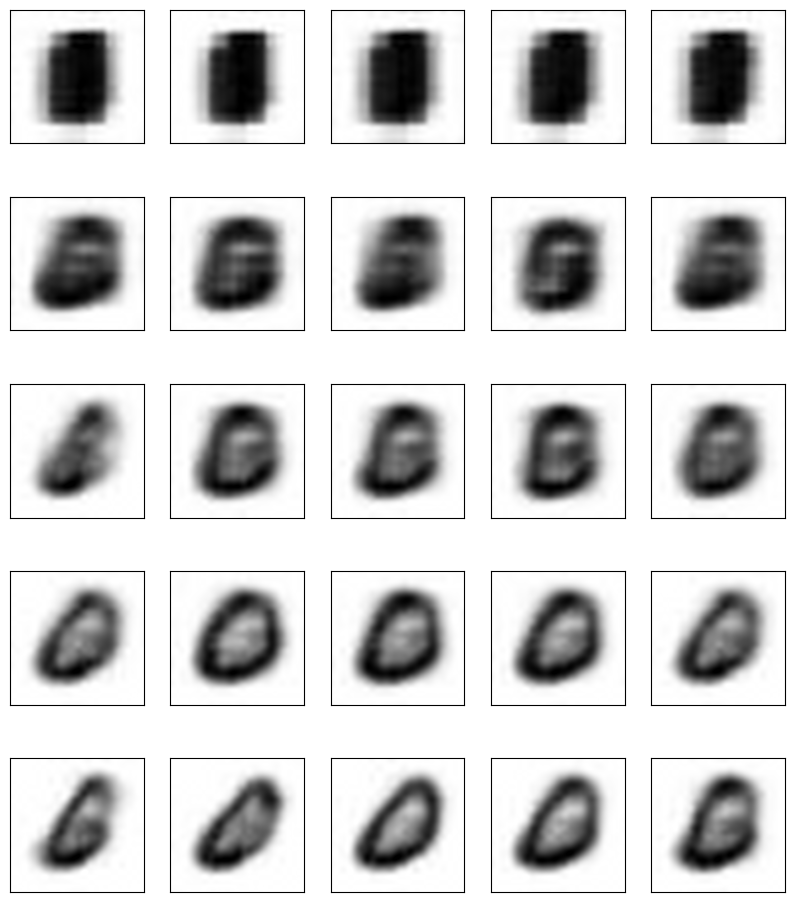

In [12]:
fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-generated')

## Annexe - Model Save and reload 

Save our model

In [13]:
os.makedirs(f'{run_dir}/models', exist_ok=True)

filename = run_dir+'/models/my_model.keras'

vae.save(filename)

Reload it

In [14]:
vae_reloaded = keras.models.load_model( filename, 
                                        custom_objects={ 'SamplingLayer': SamplingLayer, 
                                                         'VariationalLossLayer':VariationalLossLayer})

Play with our decoder !

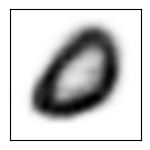

In [ ]:
decoder = vae.get_layer('decoder')

img = decoder( np.array([[-1,.1]]))
fidle.scrawler.images(img.detach().cpu().numpy(), x_size=2,y_size=2)
#pas très jolie